### Loading the Iris Dataset

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

print(f"Dataset shape: {X.shape}")
print(df.head())

Dataset shape: (150, 4)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


### Normalization: 

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

### Applying PCA and computing eigen values:

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_std)

eigenvalues = pca.explained_variance_

explained_variance_ratio = pca.explained_variance_ratio_

print("Eigenvalues (Variance of each component):")
print(eigenvalues)
print("\nExplained Variance Ratio (Proportion of variance explained):")
print(explained_variance_ratio)

print(
    f"\nTotal variance explained by 2 components: {sum(explained_variance_ratio) * 100:.2f}%")

Eigenvalues (Variance of each component):
[2.93808505 0.9201649 ]

Explained Variance Ratio (Proportion of variance explained):
[0.72962445 0.22850762]

Total variance explained by 2 components: 95.81%


## Visualizing PCA

/home/wren/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


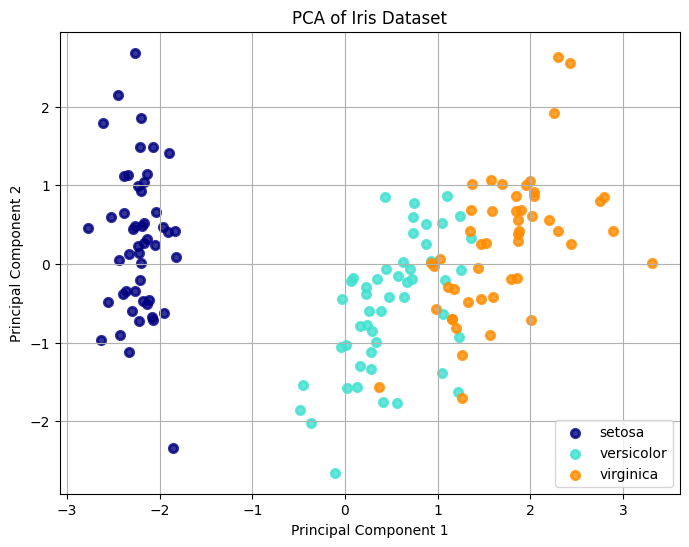

In [6]:
import matplotlib.pyplot as plt

# Define colors and target names for the plot
colors = ['navy', 'turquoise', 'darkorange']
target_names = iris.target_names

plt.figure(figsize=(8, 6))

# Plot each class separately to create a legend
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1],
                color=color, alpha=0.8, lw=2,
                label=target_name)

plt.title('PCA of Iris Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.grid(True)
plt.show()

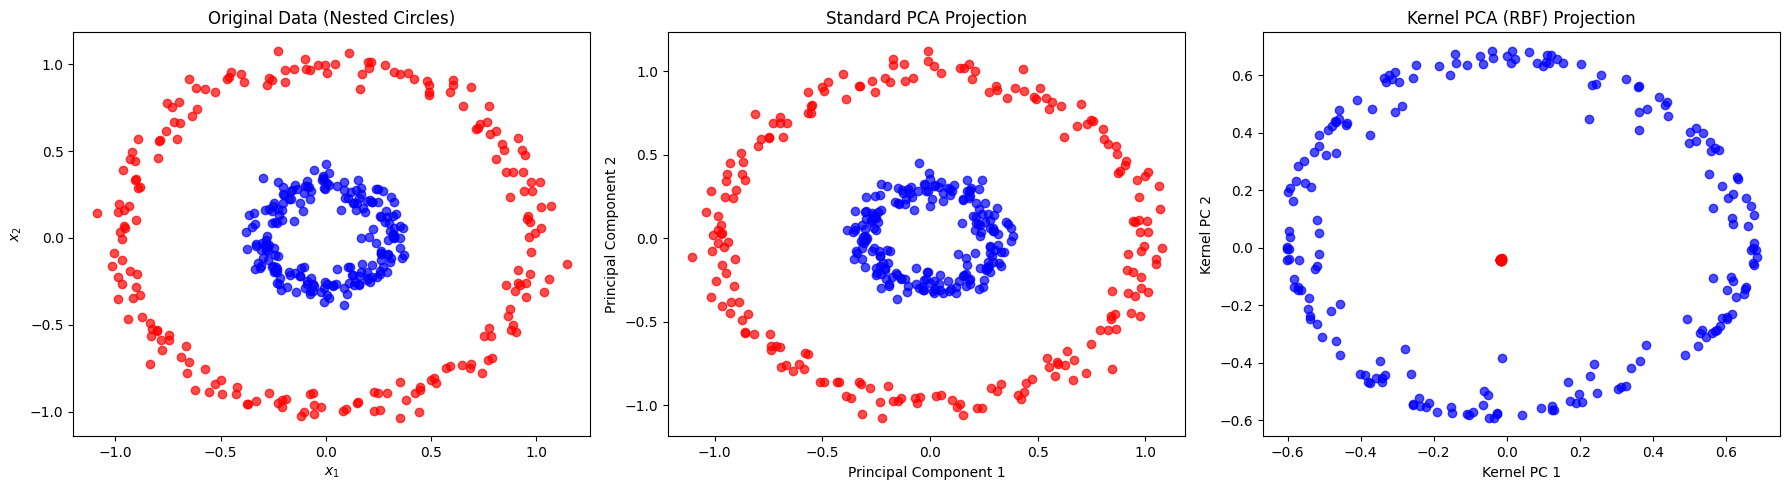

In [6]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.decomposition import PCA, KernelPCA

X_circles, y_circles = make_circles(
    n_samples=400, factor=0.3, noise=0.05, random_state=42)

pca = PCA(n_components=2)
X_pca_circles = pca.fit_transform(X_circles)

kpca = KernelPCA(n_components=2, kernel="rbf", gamma=15)
X_kpca_circles = kpca.fit_transform(X_circles)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_circles[y_circles == 0, 0],
                X_circles[y_circles == 0, 1], color='red', alpha=0.7)
axes[0].scatter(X_circles[y_circles == 1, 0],
                X_circles[y_circles == 1, 1], color='blue', alpha=0.7)
axes[0].set_title("Original Data (Nested Circles)")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")

axes[1].scatter(X_pca_circles[y_circles == 0, 0],
                X_pca_circles[y_circles == 0, 1], color='red', alpha=0.7)
axes[1].scatter(X_pca_circles[y_circles == 1, 0],
                X_pca_circles[y_circles == 1, 1], color='blue', alpha=0.7)
axes[1].set_title("Standard PCA Projection")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

axes[2].scatter(X_kpca_circles[y_circles == 0, 0],
                X_kpca_circles[y_circles == 0, 1], color='red', alpha=0.7)
axes[2].scatter(X_kpca_circles[y_circles == 1, 0],
                X_kpca_circles[y_circles == 1, 1], color='blue', alpha=0.7)
axes[2].set_title("Kernel PCA (RBF) Projection")
axes[2].set_xlabel("Kernel PC 1")
axes[2].set_ylabel("Kernel PC 2")

plt.tight_layout()
plt.show()